# Manual Adam + exact ft/pre/cross decomposition

This notebook replaces `torch.optim.AdamW` with a hand-rolled optimizer
(`simple.manual_adam.DecomposedAdam`) that carries the ft/pre/cross
decomposition as first-class state:

$$m_t = c\cdot m_t^{\mathrm{ft}} + (1-c)\cdot m_t^{\mathrm{pre}}, \qquad v_t = c^2\, v_t^{\mathrm{ft}} + (1-c)^2\, v_t^{\mathrm{pre}} + 2c(1-c)\, v_t^{\times}.$$

Those identities now hold **by construction** in fp32 — no shadow EMAs, no
`m_recon_err` to worry about. `Δθ_pred = Δθ_real` exactly (up to machine
precision), so the red line in the Taylor comparison is predicting the same
step the optimizer actually took.

### Why this is nicer

- `m_recon_err`, `delta_theta_ratio`, `delta_theta_cos` collapse to noise-floor
  values (useful as sanity checks but no longer informative about forgetting).
- The remaining gap between `black` (actual ΔL_ft) and `blue` / `red` is now
  *entirely* 3rd-order-Taylor-truncation error plus bf16 noise in the forward
  pass — not optimizer drift.
- We can freely analyse `v_ft`, `v_pre`, `v_cross` trajectories knowing they
  are the exact task-attributable components of Adam's second moment.

### Cost

Each training step does **two** fwd+bwd passes (one on the ft sub-batch, one on
the pre sub-batch) instead of one on the mixed batch. Roughly 2× slower. For
this toy model it's negligible.

### Parity guarantee

`simple.manual_adam.ManualAdam` is tested against `torch.optim.AdamW(weight_decay=0,
fused=False)` in `tests/test_manual_adam.py` — relative param diff < 1e-5 over
20 steps on a small MLP. So we trust the Adam implementation.


In [1]:
import sys, os
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

from simple import make_data, pretrain, report
from simple.manual_adam_phase import (
    manual_adam_phase, run_one_c_manual_adam,
    LOG_KEYS,
)
from simple.manual_adam import DecomposedAdam
from simple.adam_taylor import _grad_param_keys
from simple.model import make_model

%matplotlib inline

OUT = "data/manual_adam"
SEED = 42
BATCH_SIZE = 512

data = make_data(depth=3, burst_pos=3, n_a=4, n_burst_fns=4, seed=SEED)
print(f"Vocab: {data['vocab_size']}, Context: {data['context_size']}, Prompt: {data['prompt_len']}")


Vocab: 40, Context: 37, Prompt: 12


Pretrain: 0it [00:00, ?it/s]


Converged at step 750 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.5850


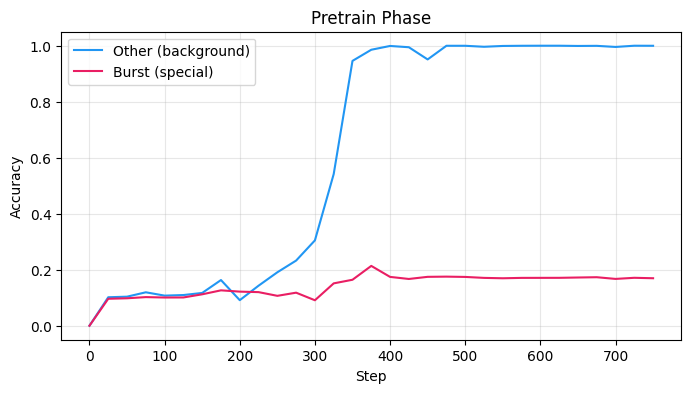

Pretrain ckpt: data/manual_adam/pretrain/pretrain_ckpt.pt


In [2]:
pt = pretrain(data, f"{OUT}/pretrain", seed=SEED, lr=1e-3, batch_size=BATCH_SIZE)
report.plot_pretrain(pt); plt.show()
print(f"Pretrain ckpt: {pt['ckpt_path']}")


## Run: pretrain → finetune@c → forget@c=0 (manual Adam)

Serial loop. Each training step does 2 fwd+bwd passes (one per sub-batch) and the decomposition is maintained by the optimizer directly. HVP uses `data["eval_burst"]` for consistency with `loss_burst`.


In [3]:
_tmp = make_model(**pt["model_cfg"], compile_model=False)
param_keys = _grad_param_keys(_tmp); del _tmp

CONCENTRATIONS = [0.25, 0.5, 0.75, 1.0]

FT_STEPS, FT_LR, FT_EVAL_EVERY = 200, 1e-4, 1
FG_STEPS, FG_LR, FG_EVAL_EVERY = 50,  1e-4, 1

runs = {}
for c in CONCENTRATIONS:
    print(f"\n===== c={c} =====")
    ft = manual_adam_phase(
        data, pt["ckpt_path"], param_keys,
        c=c, steps=FT_STEPS, lr=FT_LR, lr_end=FT_LR * 0.5,
        batch_size=BATCH_SIZE, eval_every=FT_EVAL_EVERY, seed=SEED,
        desc=f"finetune c={c}", taylor=True, hvp_on="eval",
        snapshot_dir=f"{OUT}/snapshots", snapshot_tag=f"ft_c{c}",
    )
    fg = manual_adam_phase(
        data, ft["net"], param_keys,
        c=0.0, steps=FG_STEPS, lr=FG_LR, lr_end=FG_LR * 0.5,
        batch_size=BATCH_SIZE, eval_every=FG_EVAL_EVERY, seed=SEED + 1,
        desc=f"forget from c={c}", taylor=True, hvp_on="eval",
        snapshot_dir=f"{OUT}/snapshots", snapshot_tag=f"fg_from_c{c}",
    )
    runs[c] = {"finetune": ft, "forget": fg}



===== c=0.25 =====


finetune c=0.25:   0%|          | 0/200 [00:00<?, ?it/s]

forget from c=0.25:   0%|          | 0/50 [00:00<?, ?it/s]


===== c=0.5 =====


finetune c=0.5:   0%|          | 0/200 [00:00<?, ?it/s]

...

finetune c=0.75:   0%|          | 0/200 [00:00<?, ?it/s]

forget from c=0.75:   0%|          | 0/50 [00:00<?, ?it/s]


===== c=1.0 =====


finetune c=1.0:   0%|          | 0/200 [00:00<?, ?it/s]

forget from c=1.0:   0%|          | 0/50 [00:00<?, ?it/s]

## Loss / accuracy trajectories

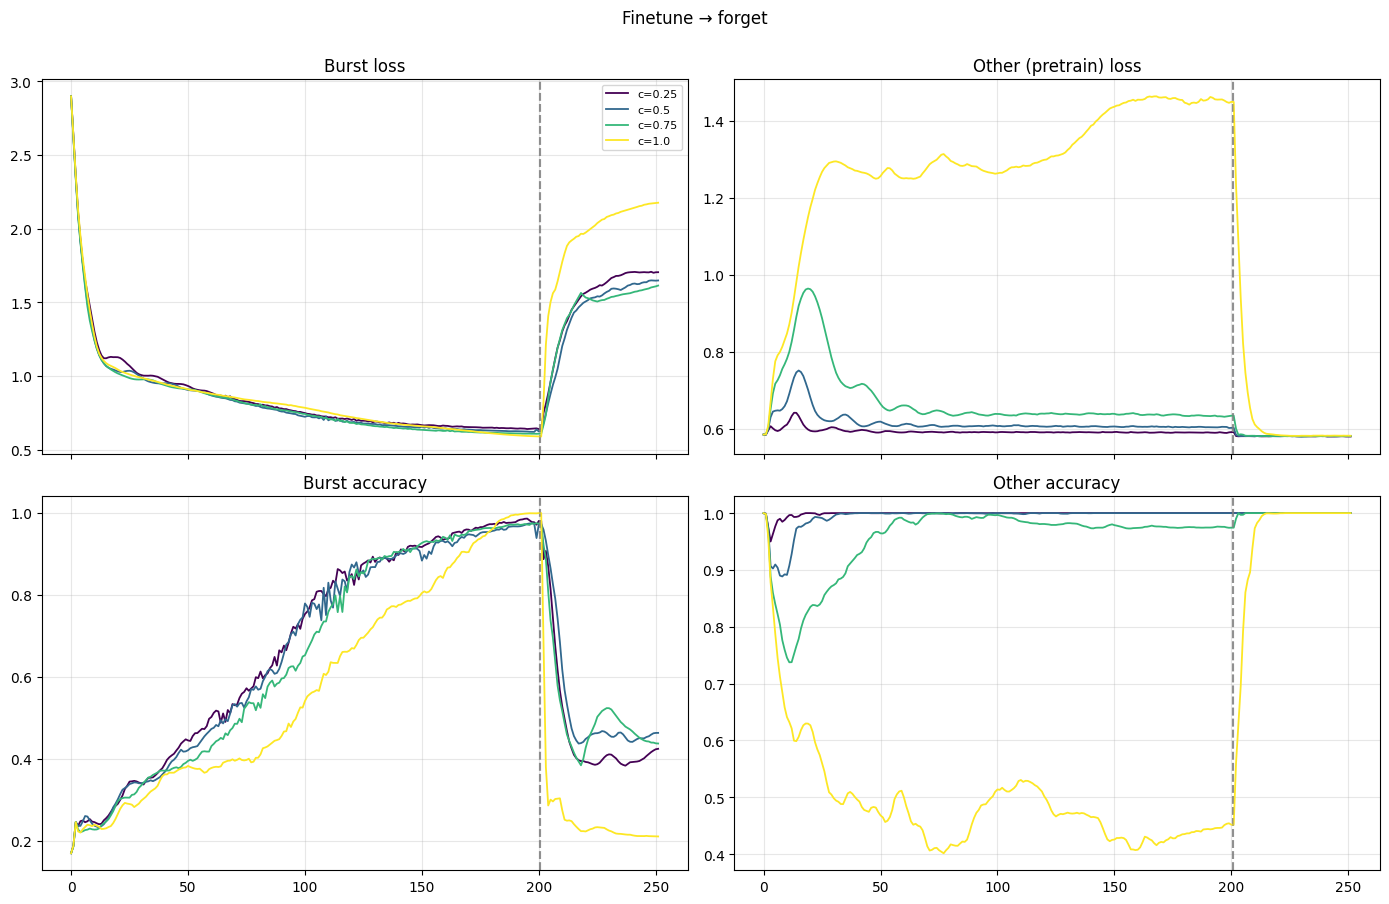

In [4]:
cmap = mpl.colormaps["viridis"]
c_colors = {c: cmap(i / max(1, len(CONCENTRATIONS) - 1)) for i, c in enumerate(CONCENTRATIONS)}

def _concat(phase_logs, key):
    ft, fg = phase_logs
    return (np.arange(len(ft[key]) + len(fg[key])),
            np.concatenate([ft[key], fg[key]]),
            len(ft[key]))

def _plot_traj(keys_titles, suptitle, nrows, ncols, figsize=(14, 9)):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True)
    axes_list = list(np.atleast_1d(axes).flatten())
    for ax, (key, title) in zip(axes_list, keys_titles):
        for c in CONCENTRATIONS:
            x, y, split = _concat((runs[c]["finetune"]["log"], runs[c]["forget"]["log"]), key)
            ax.plot(x, y, color=c_colors[c], lw=1.3, label=f"c={c}")
            ax.axvline(split - 0.5, color="gray", ls="--", alpha=0.4)
        ax.set_title(title); ax.grid(True, alpha=0.3)
    axes_list[0].legend(fontsize=8)
    fig.suptitle(suptitle, y=1.0, fontsize=12); fig.tight_layout(); plt.show()

_plot_traj(
    [("loss_burst", "Burst loss"), ("loss_other", "Other (pretrain) loss"),
     ("acc_burst", "Burst accuracy"), ("acc_other", "Other accuracy")],
    "Finetune → forget", 2, 2)

## Sanity: does `c·m̂_ft + (1-c)·m̂_pre` match the optimizer's `m̂_t`?

We built $P$ directly from the optimizer's real $v$, so there's no $v$-reconstruction to worry about. The only thing to check is the first-moment identity.

`m_recon_err` should be small at steady state (a few % tops). It's not zero because we feed independent pure-ft and pure-pre batches to the shadow EMAs, not the same sub-batches that built the mixed training gradient — so the identity holds in expectation, not step-exact.

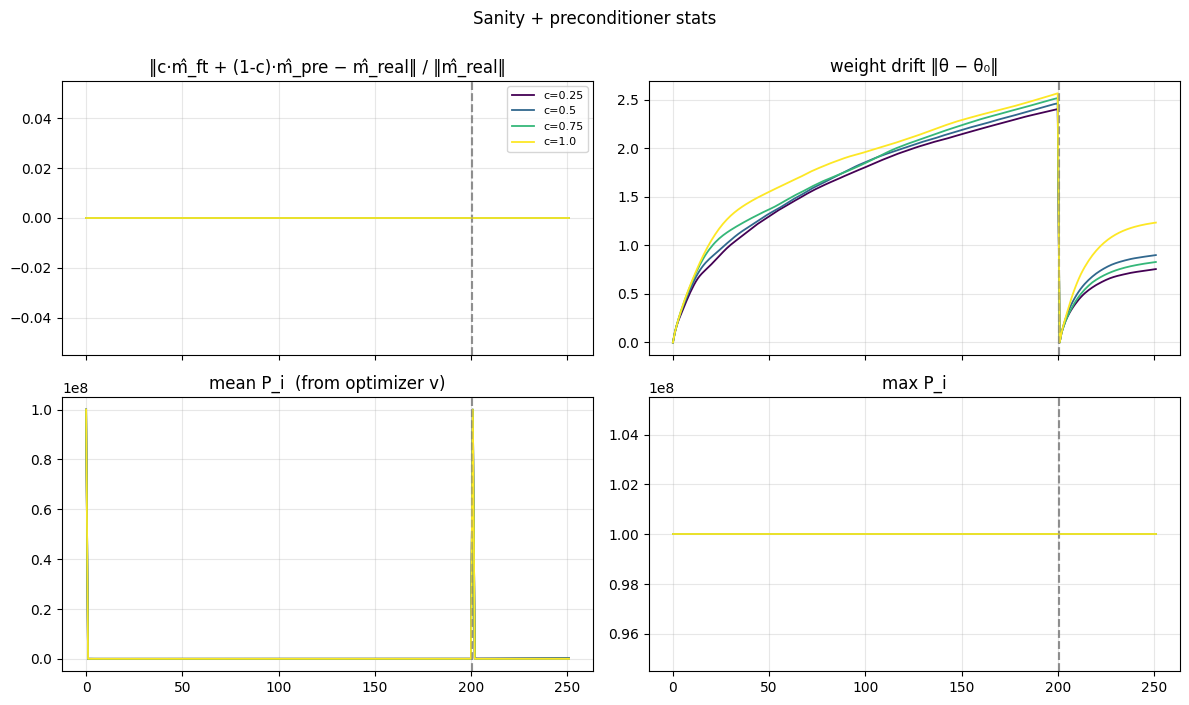

In [5]:
_plot_traj(
    [("m_recon_err", "‖c·m̂_ft + (1-c)·m̂_pre − m̂_real‖ / ‖m̂_real‖"),
     ("weight_drift", "weight drift ‖θ − θ₀‖"),
     ("P_mean",        "mean P_i  (from optimizer v)"),
     ("P_max",         "max P_i")],
    "Sanity + preconditioner stats", 2, 2, figsize=(12, 7))

## Diagnostic: predicted Δθ vs real Δθ

With Fix 5 (step-exact batch split), the shadow EMAs should reconstruct AdamW's `m̂_t` almost exactly, and therefore `Δθ_pred = -η·P·(c·m̂_ft + (1-c)·m̂_pre)` should match the observed `Δθ_real = θ_now - θ_prev`.

Two panels:

- **ratio**: `||Δθ_pred|| / ||Δθ_real||`. Should sit tight at 1.0.
- **cosine**: `cos(Δθ_pred, Δθ_real)`. Should sit tight at 1.0.

If these look good, the red-line gap in the Taylor plot should close up. If they're still off, the residual is bf16 precision or a subtler issue (gradient clipping, autocast).


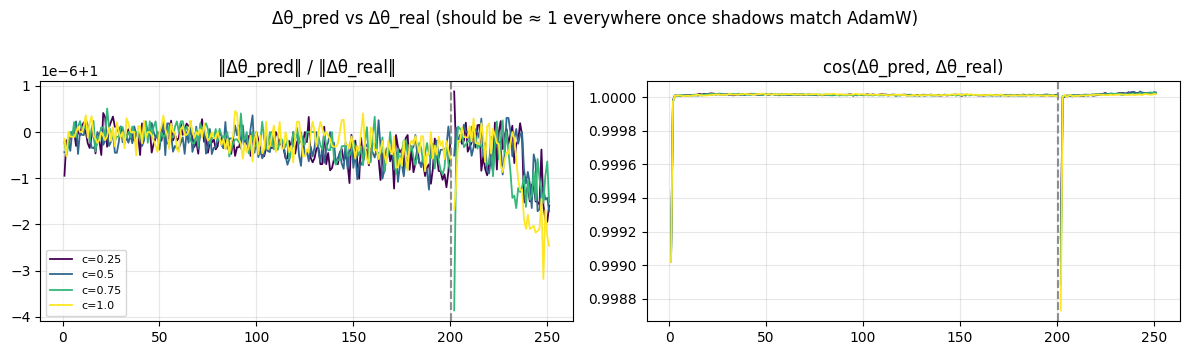

c=0.25  finetune  ratio median=1.0000  min/max=1.000/1.000  |  cos median=1.00001  min=0.99904
c=0.25  forget    ratio median=1.0000  min/max=1.000/1.000  |  cos median=1.00002  min=0.99916
c=0.5  finetune  ratio median=1.0000  min/max=1.000/1.000  |  cos median=1.00001  min=0.99902
c=0.5  forget    ratio median=1.0000  min/max=1.000/1.000  |  cos median=1.00002  min=0.99903
c=0.75  finetune  ratio median=1.0000  min/max=1.000/1.000  |  cos median=1.00001  min=0.99902
c=0.75  forget    ratio median=1.0000  min/max=1.000/1.000  |  cos median=1.00002  min=0.99888
c=1.0  finetune  ratio median=1.0000  min/max=1.000/1.000  |  cos median=1.00002  min=0.99902
c=1.0  forget    ratio median=1.0000  min/max=1.000/1.000  |  cos median=1.00001  min=0.99873


In [6]:
_plot_traj(
    [("delta_theta_ratio", "‖Δθ_pred‖ / ‖Δθ_real‖"),
     ("delta_theta_cos",   "cos(Δθ_pred, Δθ_real)")],
    "Δθ_pred vs Δθ_real (should be ≈ 1 everywhere once shadows match AdamW)",
    1, 2, figsize=(12, 3.5))

# Also summarize numerically
for c in CONCENTRATIONS:
    for ph in ("finetune", "forget"):
        log = runs[c][ph]["log"]
        mask = log["step"] >= 0
        r = log["delta_theta_ratio"][mask]; co = log["delta_theta_cos"][mask]
        r = r[~np.isnan(r)]; co = co[~np.isnan(co)]
        print(f"c={c}  {ph:<8s}  ratio median={np.median(r):.4f}  min/max={r.min():.3f}/{r.max():.3f}  "
              f"|  cos median={np.median(co):.5f}  min={co.min():.5f}")


## Shadow first moments

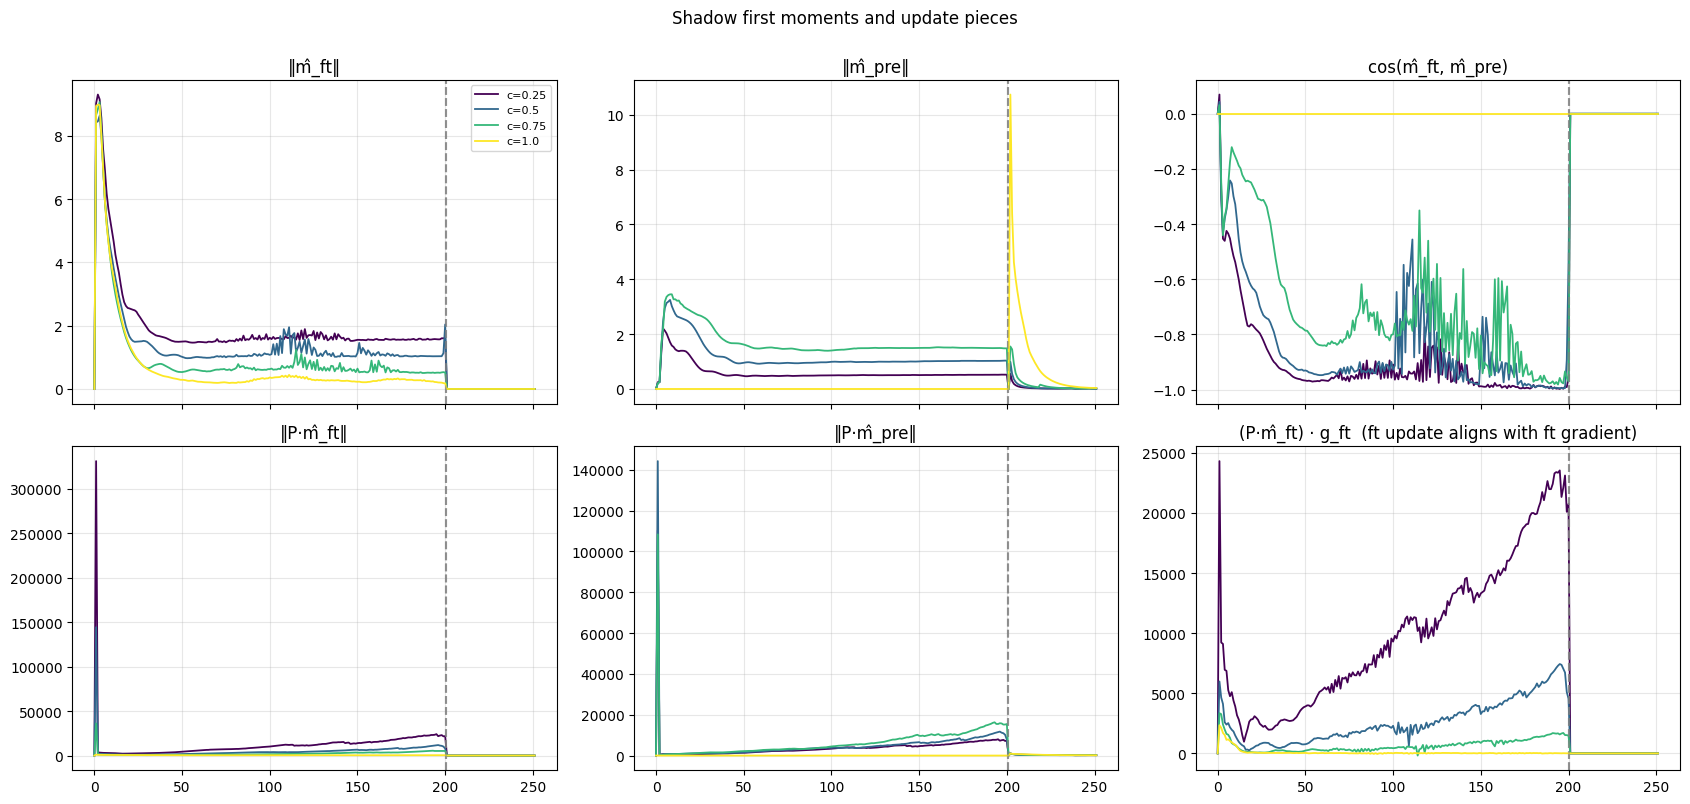

In [7]:
_plot_traj(
    [("m_ft_norm",  "‖m̂_ft‖"),
     ("m_pre_norm", "‖m̂_pre‖"),
     ("cos_m_ft_m_pre", "cos(m̂_ft, m̂_pre)"),
     ("u_ft_norm",  "‖P·m̂_ft‖"),
     ("u_pre_norm", "‖P·m̂_pre‖"),
     ("u_ft_dot_g_ft", "(P·m̂_ft) · g_ft  (ft update aligns with ft gradient)")],
    "Shadow first moments and update pieces", 2, 3, figsize=(17, 8))

## The 5 Taylor terms over time

One panel per term, one line per $c$, across finetune→forget. All five share the same sign convention as the SGD version:

- $T_1 < 0$: replay is helping (the c-fraction of the update pushes ΔL_ft down).
- $T_2 < 0$ or $> 0$: pretrain-gradient step helps burst (first-order conflict in either direction).
- $T_3, T_5 \ge 0$ if curvature is PSD; can flip sign in concave regions.
- $T_4$ sign = "cross curvature damage".

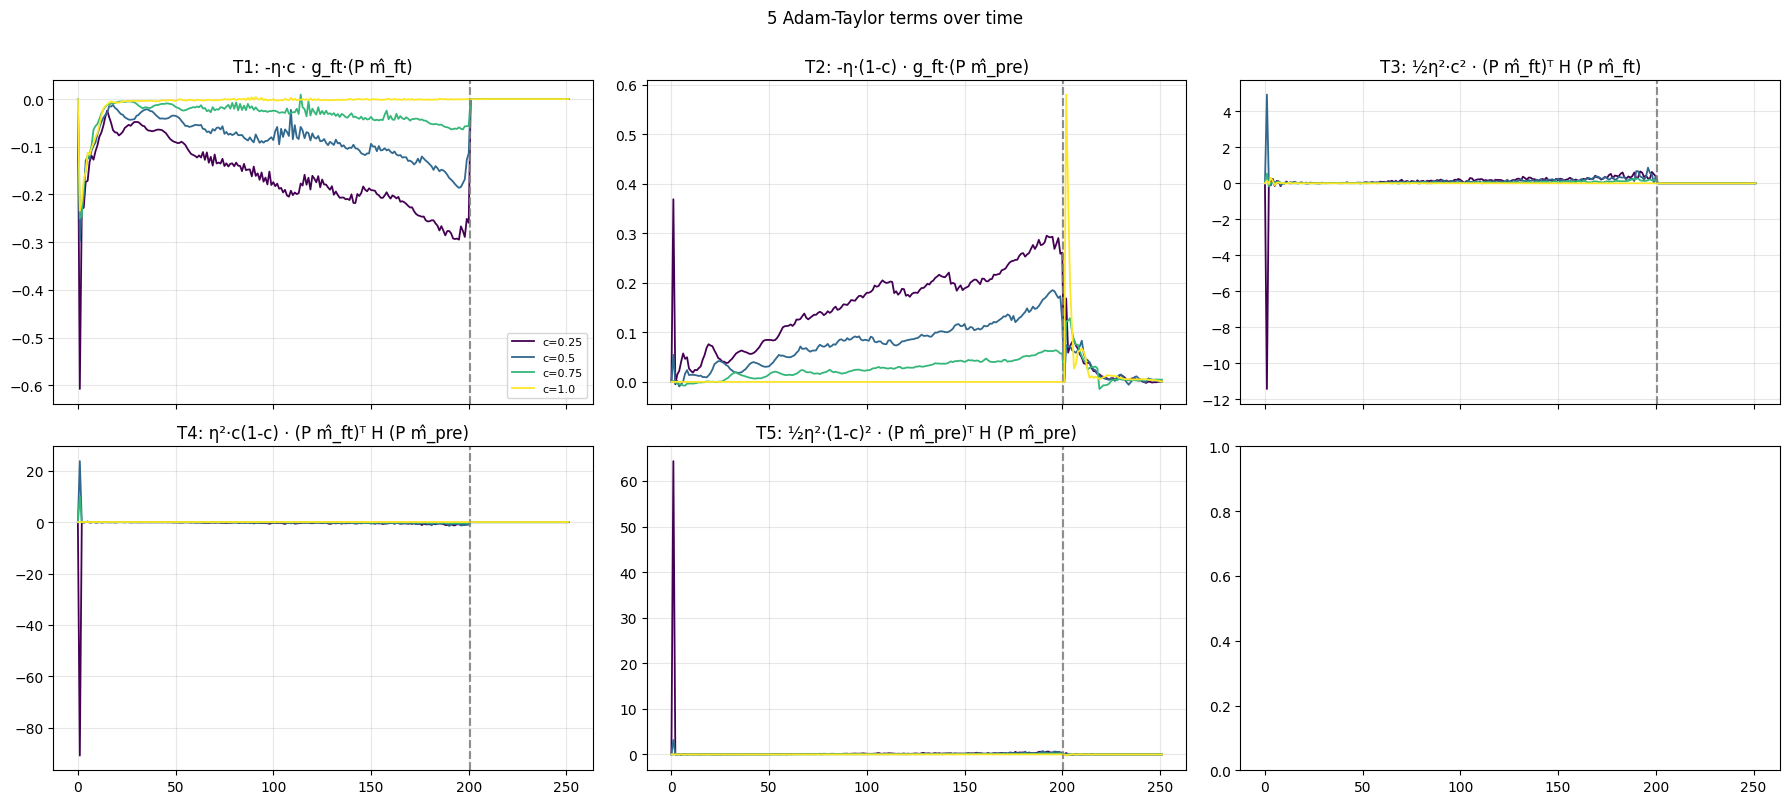

In [8]:
term_names = [
    "T1: -η·c · g_ft·(P m̂_ft)",
    "T2: -η·(1-c) · g_ft·(P m̂_pre)",
    "T3: ½η²·c² · (P m̂_ft)ᵀ H (P m̂_ft)",
    "T4: η²·c(1-c) · (P m̂_ft)ᵀ H (P m̂_pre)",
    "T5: ½η²·(1-c)² · (P m̂_pre)ᵀ H (P m̂_pre)",
]
_plot_traj(
    [(f"T{i+1}", term_names[i]) for i in range(5)],
    "5 Adam-Taylor terms over time", 2, 3, figsize=(18, 8))

## Cumulative Taylor prediction vs actual ΔL_ft

For each phase, accumulate:

- $\sum (T_1 + T_2) - \sum (T_3 + T_4 + T_5)$ — predicted ΔL_ft from the 5 Taylor terms
- $\sum (A_{\mathrm{first}} - A_{\mathrm{quad}})$ — Taylor using the *actual* observed $\Delta\theta$
- $L_{\mathrm{ft}}(\theta_T) - L_{\mathrm{ft}}(\theta_0)$ — ground truth

**Sign note.** We evaluate `g`, `H`, `m̂`, `P` at the *end* of each interval (θ_t), not the start (θ_{t-1}). With end-of-interval evaluation, the correct Taylor formula is

$$\Delta L \approx g(\theta_t)\cdot\Delta\theta - \tfrac{1}{2}\,\Delta\theta^\top H(\theta_t)\,\Delta\theta$$

(minus on the quadratic), because `g(θ_t) = g(θ_{t-1}) + H·Δθ` already contains the full quadratic once. That's why the cumulative plot uses `cum(T1+T2) − cum(T3+T4+T5)` and `cum(A_first − A_quad)`. See the quadratic-loss sanity check in the chat log for a numerical example.

If black ≈ `A_first - A_quad`, 2nd-order Taylor is a valid truncation for the real Δθ.
If black ≈ `(T1+T2) - (T3+T4+T5)`, the decomposition-predicted Δθ also matches real Adam.


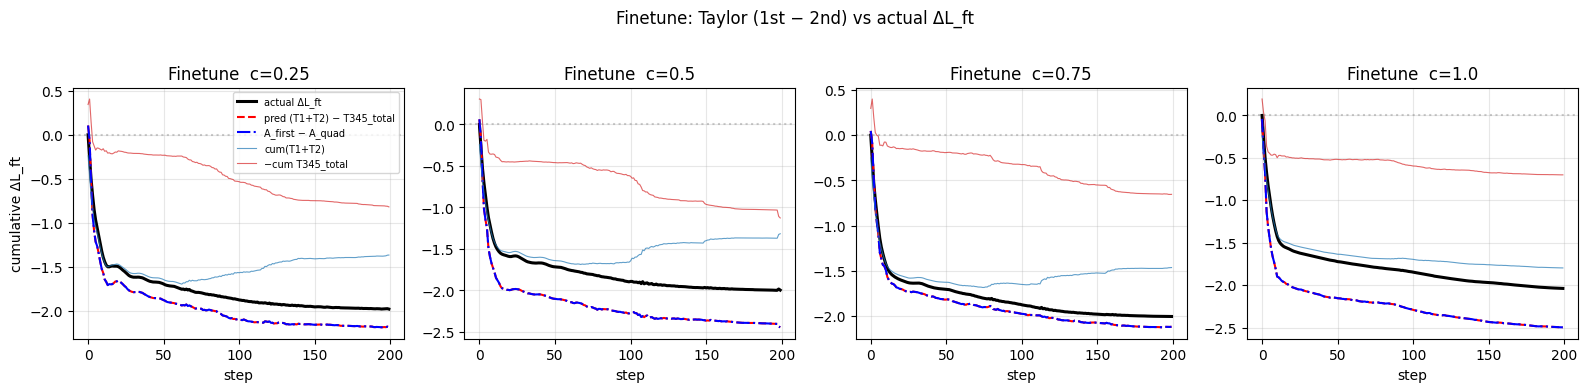

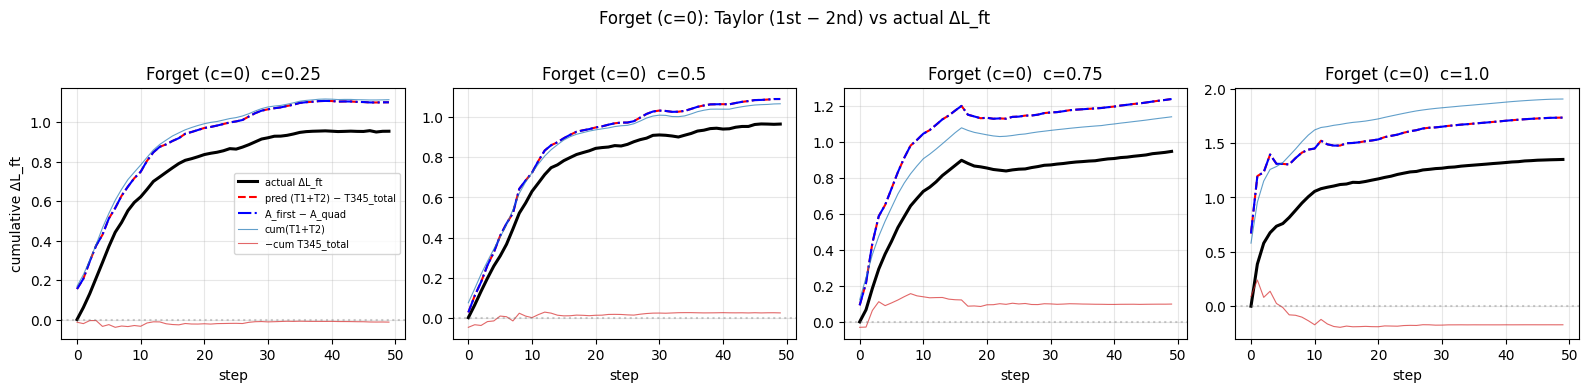

In [9]:
def _taylor_curves(log):
    """Return (x, cum_first, cum_second_total, cum_A_corrected, cum_actual_dL).

    `cum_second_total` uses `T345_total` — a single HVP on the assembled Δθ_pred —
    rather than the sum T3+T4+T5 of individually-computed bilinears. Those individual
    bilinears can be astronomically large in directions where g_ft and g_pre cancel
    (because u_ft = P·m̂_ft and u_pre = P·m̂_pre are huge, while their combination
    Δθ_pred is bounded). Algebraically the three terms must cancel to give
    ½·Δθ_pred^T H Δθ_pred, but HVP noise breaks that cancellation when they are
    computed separately.
    """
    mask = log["step"] >= 0
    steps = log["step"][mask]
    T1, T2 = (np.nan_to_num(log[f"T{i+1}"][mask]) for i in range(2))
    if "T345_total" in log and not np.all(np.isnan(log["T345_total"][mask])):
        T345 = np.nan_to_num(log["T345_total"][mask])
    else:
        # Fallback for logs produced before the stable-total fix.
        T345 = np.nan_to_num(log["T3"][mask] + log["T4"][mask] + log["T5"][mask])
    cum_first  = np.cumsum(T1 + T2)
    cum_second = np.cumsum(T345)
    a_first = np.nan_to_num(log["A_first"][mask])
    a_quad  = np.nan_to_num(log["A_quad"][mask])
    cum_A   = np.cumsum(a_first - a_quad)       # end-of-interval sign
    lb = log["loss_burst"][mask]
    cum_actual = lb - lb[0]
    return steps, cum_first, cum_second, cum_A, cum_actual

for phase_key, phase_name in [("finetune", "Finetune"), ("forget", "Forget (c=0)")]:
    fig, axes = plt.subplots(1, len(CONCENTRATIONS),
                              figsize=(4*len(CONCENTRATIONS), 3.8))
    for ax, c in zip(np.atleast_1d(axes), CONCENTRATIONS):
        x, cf, cs, ca, cdl = _taylor_curves(runs[c][phase_key]["log"])
        ax.plot(x, cdl,      "k-",  lw=2.2, label="actual ΔL_ft")
        ax.plot(x, cf - cs,  "r--", lw=1.5, label="pred (T1+T2) − T345_total")
        ax.plot(x, ca,       "b-.", lw=1.5, label="A_first − A_quad")
        ax.plot(x, cf, color="#1f77b4", lw=0.8, alpha=0.7, label="cum(T1+T2)")
        ax.plot(x, -cs, color="#d62728", lw=0.8, alpha=0.7, label="−cum T345_total")
        ax.axhline(0, color="gray", ls=":", alpha=0.4)
        ax.set_title(f"{phase_name}  c={c}"); ax.grid(True, alpha=0.3)
        ax.set_xlabel("step")
    axes[0].legend(fontsize=7); axes[0].set_ylabel("cumulative ΔL_ft")
    fig.suptitle(f"{phase_name}: Taylor (1st − 2nd) vs actual ΔL_ft", y=1.02)
    fig.tight_layout(); plt.show()


## End-of-phase 5-term breakdown (bar chart per c)

Totals of the 5 Taylor terms at phase end, for each $c$. Black dots = actual ΔL_ft. This is the "single picture" summary of which term contributes how much.

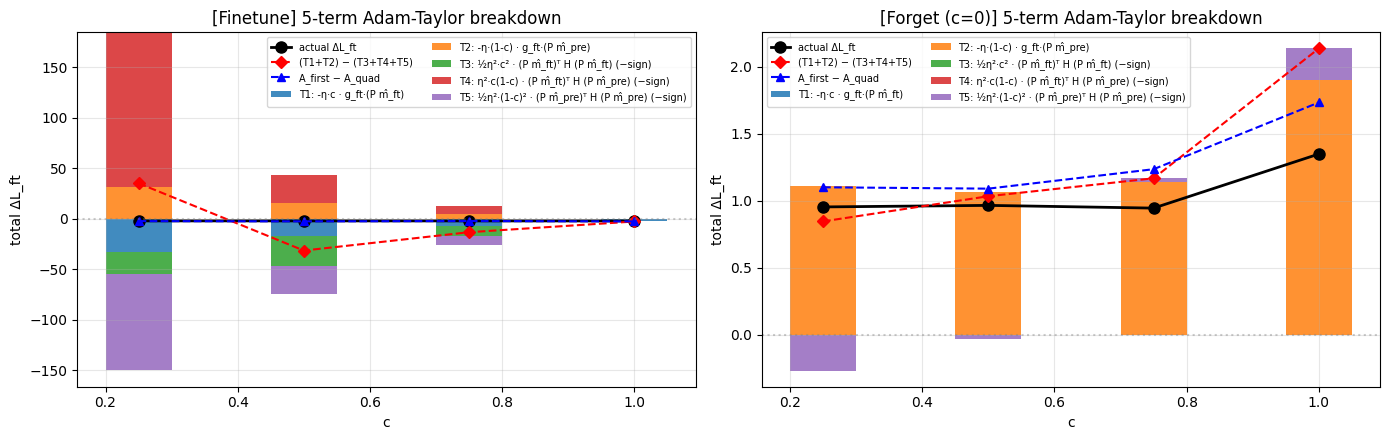

In [10]:
term_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
cs_arr = np.array(CONCENTRATIONS)

def _phase_totals(phase_key):
    """End-of-phase totals. The predicted ΔL uses the end-of-interval sign
    convention: ΔL ≈ (T1+T2) - (T3+T4+T5), and A_pred = A_first - A_quad."""
    T = np.zeros((len(cs_arr), 5))
    act = np.zeros(len(cs_arr))
    A = np.zeros(len(cs_arr))
    for i, c in enumerate(CONCENTRATIONS):
        log = runs[c][phase_key]["log"]
        mask = log["step"] >= 0
        for j in range(5):
            T[i, j] = np.nansum(log[f"T{j+1}"][mask])
        act[i] = log["loss_burst"][-1] - log["loss_burst"][mask][0]
        A[i] = np.nansum(log["A_first"][mask] - log["A_quad"][mask])
    return T, act, A

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (phase_key, name) in zip(axes, [("finetune", "Finetune"), ("forget", "Forget (c=0)")]):
    T, act, A = _phase_totals(phase_key)
    # For the stacked bars, flip the sign of the quadratic terms (T3, T4, T5)
    # so the stacked-bar total equals the corrected Taylor prediction.
    T_for_stack = T.copy()
    T_for_stack[:, 2:] *= -1.0
    bp = np.zeros(len(cs_arr)); bn = np.zeros(len(cs_arr)); w = 0.1
    for j in range(5):
        v = T_for_stack[:, j]
        pos = np.where(v > 0, v, 0)
        neg = np.where(v < 0, v, 0)
        lbl = term_names[j] + (" (−sign)" if j >= 2 else "")
        ax.bar(cs_arr, pos, bottom=bp, width=w, color=term_colors[j], alpha=0.85, label=lbl)
        ax.bar(cs_arr, neg, bottom=bn, width=w, color=term_colors[j], alpha=0.85)
        bp += pos; bn += neg
    pred_total = T[:, :2].sum(1) - T[:, 2:].sum(1)
    ax.plot(cs_arr, act,         "ko-",  lw=2, ms=8, label="actual ΔL_ft")
    ax.plot(cs_arr, pred_total,  "rD--", ms=6,    label="(T1+T2) − (T3+T4+T5)")
    ax.plot(cs_arr, A,           "b^--", ms=6,    label="A_first − A_quad")
    ax.axhline(0, color="gray", ls=":", alpha=0.4)
    ax.set_title(f"[{name}] 5-term Adam-Taylor breakdown"); ax.grid(True, alpha=0.3)
    ax.set_xlabel("c"); ax.set_ylabel("total ΔL_ft")
    ax.legend(fontsize=7, ncol=2)
fig.tight_layout(); plt.show()


## Rayleigh quotient — curvature along actual Δθ

`rayleigh_actual = 2·A_quad / ||Δθ||²`. This is the "effective eigenvalue" of $H_{\mathrm{ft}}$ in the direction the optimizer actually moved. Positive = moving into convex burst-loss curvature; negative = concave. Helps explain why the 2nd-order total can be negative (cross-entropy Hessian is not PSD).

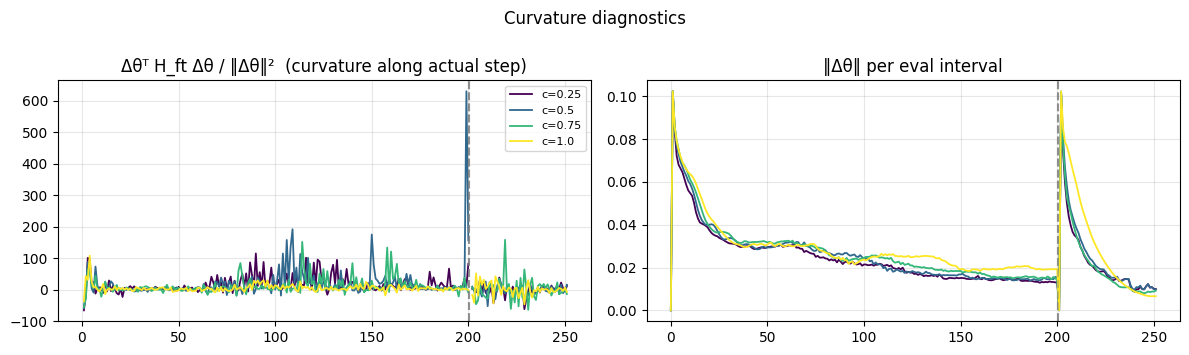

In [11]:
_plot_traj(
    [("rayleigh_actual", "Δθᵀ H_ft Δθ / ‖Δθ‖²  (curvature along actual step)"),
     ("delta_theta_norm", "‖Δθ‖ per eval interval")],
    "Curvature diagnostics", 1, 2, figsize=(12, 3.5))

## Summary table

In [12]:
print(f"{'c':>5s}  {'ft_end lb':>10s} {'ft_end ab':>9s}  {'fg_end lb':>10s} {'fg_end ab':>9s}  "
      f"{'Δab':>8s}  {'m_recon':>8s}  {'T1+T2':>10s} {'-(T3+T4+T5)':>12s}  {'pred':>10s}  {'actual':>10s}")
for c in CONCENTRATIONS:
    ft = runs[c]["finetune"]["log"]; fg = runs[c]["forget"]["log"]
    d_ab = fg["acc_burst"][-1] - ft["acc_burst"][-1]
    mask = ft["step"] >= 0
    T12 = np.nansum(ft["T1"][mask] + ft["T2"][mask])
    T345 = np.nansum(ft["T3"][mask] + ft["T4"][mask] + ft["T5"][mask])
    pred = T12 - T345
    actual = ft["loss_burst"][-1] - ft["loss_burst"][mask][0]
    print(f"{c:>5.2f}  {ft['loss_burst'][-1]:>10.4f} {ft['acc_burst'][-1]:>9.3f}  "
          f"{fg['loss_burst'][-1]:>10.4f} {fg['acc_burst'][-1]:>9.3f}  {d_ab:>+8.3f}  "
          f"{ft['m_recon_err'][-1]:>8.3f}  {T12:>+10.4f} {-T345:>+12.4f}  "
          f"{pred:>+10.4f}  {actual:>+10.4f}")


    c   ft_end lb ft_end ab   fg_end lb fg_end ab       Δab   m_recon       T1+T2  -(T3+T4+T5)        pred      actual
 0.25      0.6396     0.980      1.7044     0.424    -0.556     0.000     -1.3674     +36.6214    +35.2539     -1.9818
 0.50      0.6235     0.973      1.6482     0.463    -0.509     0.000     -1.3169     -30.0336    -31.3504     -1.9954
 0.75      0.6082     0.974      1.6136     0.437    -0.536     0.000     -1.4622     -11.7220    -13.1842     -2.0026
 1.00      0.5891     0.999      2.1759     0.211    -0.789     0.000     -1.7957      -0.7834     -2.5791     -2.0371


In [13]:
# Per-step diagnostic: compare A_quad vs T3+T4+T5 (and A_first vs T1+T2) directly.
# If red-matches-black but blue-does-not, one of these pairs must disagree significantly.
import pandas as pd  # just for nice formatting; np works too

for c in CONCENTRATIONS:
    print(f"\n===== c={c}  (finetune, first 5 and last 5 steps) =====")
    log = runs[c]["finetune"]["log"]
    mask = log["step"] >= 0
    idx = np.where(mask)[0]
    show = np.concatenate([idx[:5], idx[-5:]])
    T12 = log["T1"][show] + log["T2"][show]
    T345 = log["T3"][show] + log["T4"][show] + log["T5"][show]
    A1 = log["A_first"][show]; Aq = log["A_quad"][show]
    dL = log["dL_actual"][show]
    rows = []
    for i, s in enumerate(show):
        rows.append(dict(
            step=int(log["step"][s]),
            dL_actual=dL[i],
            A_first=A1[i], A_quad=Aq[i], A_first_minus_A_quad=A1[i]-Aq[i],
            T12=T12[i], T345=T345[i], pred=T12[i]-T345[i],
            ratio_T12_over_Afirst=(T12[i]/A1[i]) if A1[i] else np.nan,
            ratio_T345_over_Aquad=(T345[i]/Aq[i]) if Aq[i] else np.nan,
        ))
    df = pd.DataFrame(rows)
    print(df.to_string(index=False, float_format=lambda x: f"{x:+.5f}"))



===== c=0.25  (finetune, first 5 and last 5 steps) =====
 step  dL_actual  A_first   A_quad  A_first_minus_A_quad      T12      T345      pred  ratio_T12_over_Afirst  ratio_T345_over_Aquad
    0   -0.27665 -0.23908 -0.34442              +0.10533 -0.23908 -37.89287 +37.65379               +1.00000             +110.01975
    1   -0.26406 -0.23535 -0.06233              -0.17302 -0.23535  +0.13887  -0.37422               +1.00000               -2.22784
    2   -0.24457 -0.21283 +0.26256              -0.47539 -0.21283  -0.10894  -0.10390               +1.00000               -0.41492
    3   -0.18340 -0.15146 +0.22360              -0.37506 -0.15146  +0.35767  -0.50913               +1.00000               +1.59962
    4   -0.16071 -0.13044 +0.04592              -0.17636 -0.13044  -0.03350  -0.09694               +1.00000               -0.72956
  195   +0.00130 +0.00150 +0.00018              +0.00132 +0.00150  -0.07556  +0.07706               +0.99999             -430.78505
  196   +0.00115 +